In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torchvision import transforms
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Updated Path for Google Drive
# Adjust this path to where your 'kvasir-capsule' folder is located in your Drive
DATA_DIR = '/content/drive/MyDrive//kvasir-capsule'

print("Setup done. Drive mounted.")

Mounted at /content/drive
Setup done. Drive mounted.


<h1> Task 1: Dataset Exploration and Imbalance Analysis</h1>

In [2]:
data = []

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            data.append((img_path, class_name))

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total images:", len(df))
df.head()

Total images: 42957


,image_path,label
0,/content/drive/MyDrive//kvasir-capsule/Polyp/1...,Polyp
1,/content/drive/MyDrive//kvasir-capsule/Polyp/1...,Polyp
2,/content/drive/MyDrive//kvasir-capsule/Polyp/1...,Polyp
3,/content/drive/MyDrive//kvasir-capsule/Polyp/1...,Polyp
4,/content/drive/MyDrive//kvasir-capsule/Polyp/1...,Polyp


In [3]:
class_counts = df["label"].value_counts()

print(class_counts)

label
Normal clean mucosa     30017
Ileocecal valve          4189
Reduced mucosal view     2933
Pylorus                  1529
Angiectasia               879
Ulcer                     854
Foreign body              776
Lymphangiectasia          592
Erosion                   506
Blood - fresh             446
Erythema                  159
Polyp                      55
Blood - hematin            12
Ampulla of vater           10
Name: count, dtype: int64


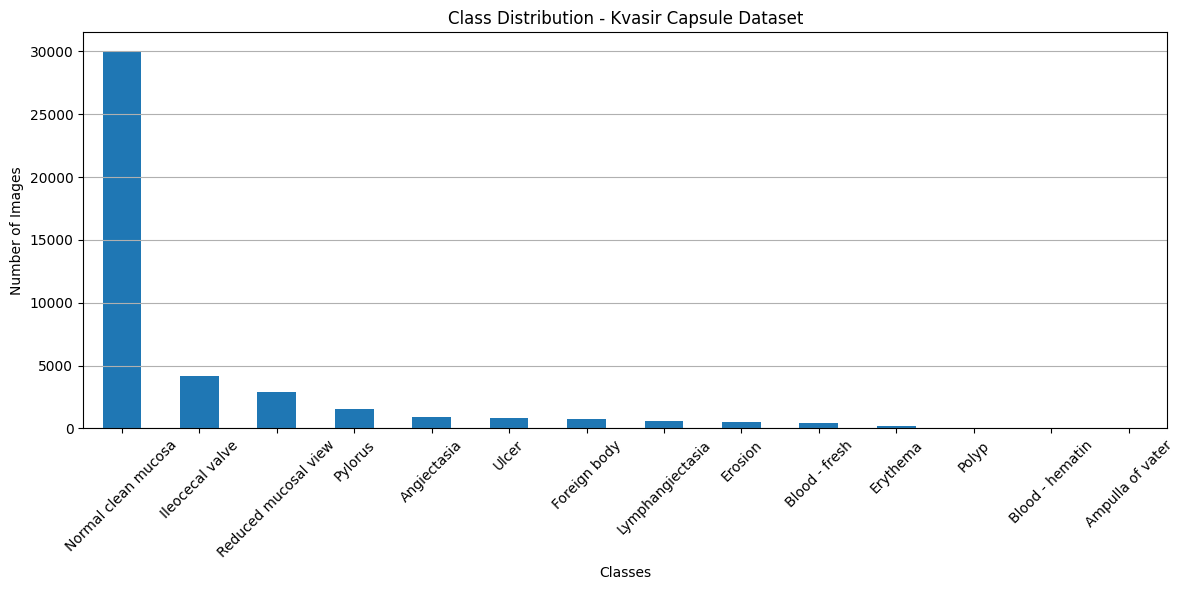

In [4]:
plt.figure(figsize=(12,6))
class_counts.plot(kind='bar')

plt.title("Class Distribution - Kvasir Capsule Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [5]:
max_class = class_counts.idxmax()
min_class = class_counts.idxmin()

print("Majority Class:", max_class, "->", class_counts[max_class])
print("Minority Class:", min_class, "->", class_counts[min_class])

Majority Class: Normal clean mucosa -> 30017
Minority Class: Ampulla of vater -> 10


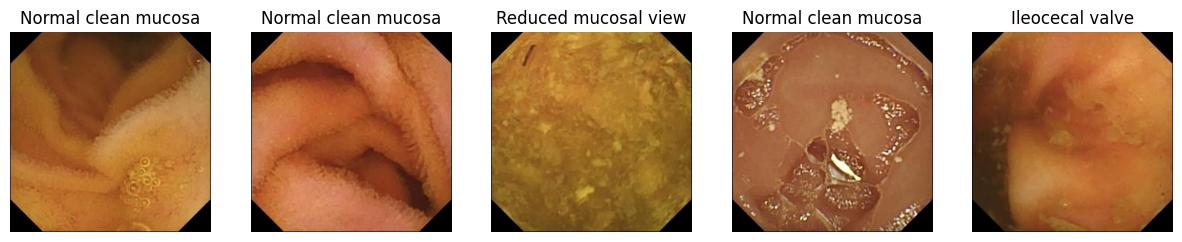

In [6]:
import matplotlib.pyplot as plt

def show_samples(df, n=5):
    plt.figure(figsize=(15,8))

    for i, (img_path, label) in enumerate(df.sample(n).values):
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.show()

show_samples(df, n=5)

### Why Class Imbalance is Critical in Medical Diagnosis

Class imbalance is a major challenge in medical image classification because models tend to become biased toward majority classes, leading to poor detection of rare but critical conditions. In gastrointestinal diagnosis, minority classes such as ulcers or polyps may represent serious diseases. If the model fails to learn these patterns properly, it can result in false negatives, which are dangerous in real-world scenarios. Therefore, handling imbalance is essential to ensure reliable and clinically useful predictions.

<h1>Task 2: Under-Sampling (Majority Class Control)</h1>

In [7]:
THRESHOLD = 200
print("Under-sampling threshold:", THRESHOLD)

Under-sampling threshold: 200


In [8]:
balanced_data = []

for label, group in df.groupby("label"):
    if len(group) > THRESHOLD:
        sampled_group = group.sample(THRESHOLD, random_state=SEED)
    else:
        sampled_group = group

    balanced_data.append(sampled_group)

df_under = pd.concat(balanced_data).reset_index(drop=True)

print("New dataset size:", len(df_under))
df_under.head()

New dataset size: 2236


,image_path,label
0,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater
1,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater
2,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater
3,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater
4,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater


In [9]:
under_counts = df_under["label"].value_counts()
print(under_counts)

label
Angiectasia             200
Blood - fresh           200
Erosion                 200
Lymphangiectasia        200
Ileocecal valve         200
Foreign body            200
Pylorus                 200
Reduced mucosal view    200
Ulcer                   200
Normal clean mucosa     200
Erythema                159
Polyp                    55
Blood - hematin          12
Ampulla of vater         10
Name: count, dtype: int64


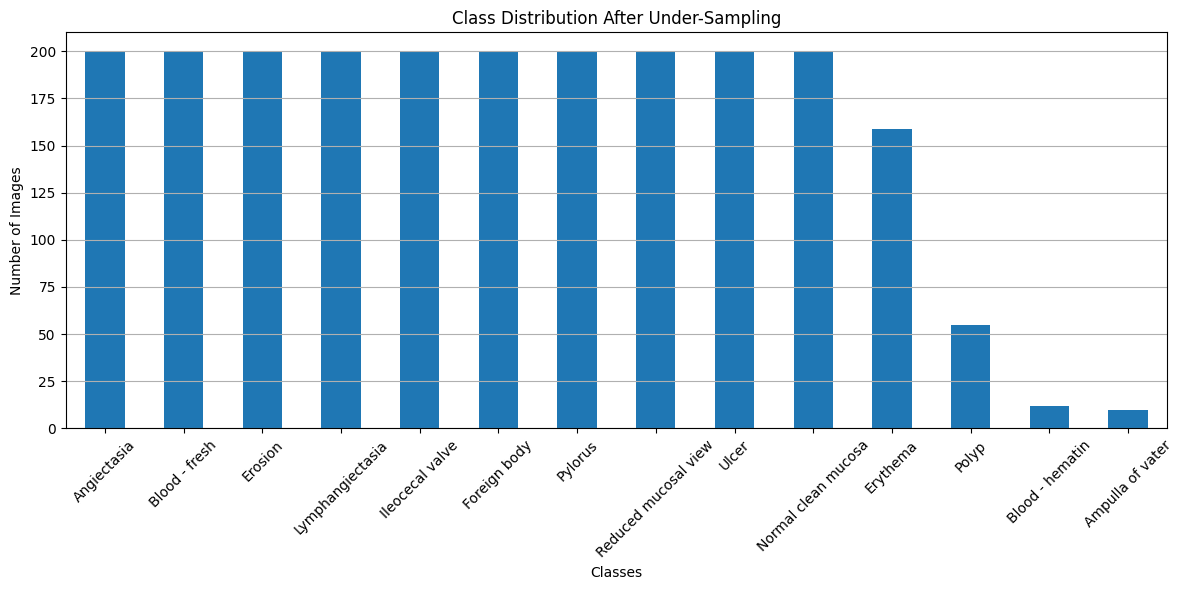

In [10]:
plt.figure(figsize=(12,6))
under_counts.plot(kind='bar')

plt.title("Class Distribution After Under-Sampling")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [11]:
comparison_df = pd.DataFrame({
    "Before": class_counts,
    "After": under_counts
}).fillna(0)

comparison_df

,Before,After
label,,
Ampulla of vater,10,10
Angiectasia,879,200
Blood - fresh,446,200
Blood - hematin,12,12
Erosion,506,200
Erythema,159,159
Foreign body,776,200
Ileocecal valve,4189,200
Lymphangiectasia,592,200


In [12]:
original_size = len(df)
new_size = len(df_under)

data_loss = original_size - new_size

print("Original dataset:", original_size)
print("After under-sampling:", new_size)
print("Total data removed:", data_loss)

Original dataset: 42957
After under-sampling: 2236
Total data removed: 40721


### Observation: Under-Sampling

Under-sampling successfully reduces the dominance of majority classes by limiting them to a fixed threshold. This helps in creating a more balanced dataset and prevents the model from becoming biased toward frequently occurring classes. However, this approach leads to loss of potentially useful data, as many samples from majority classes are discarded. While it improves fairness in training, it may reduce the model’s ability to generalize fully due to reduced data diversity.

<h1>Task 3: Data Augmentation–Based Over-Sampling</h1>

In [13]:
from torchvision import transforms

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [14]:
oversampled_data = []

for label, group in df_under.groupby("label"):
    count = len(group)

    if count < THRESHOLD:
        needed = THRESHOLD - count

        sampled_rows = group.sample(needed, replace=True, random_state=SEED)

        for _, row in sampled_rows.iterrows():
            oversampled_data.append((row["image_path"], label, True))  # augmented

    # original data
    for _, row in group.iterrows():
        oversampled_data.append((row["image_path"], label, False))  # original

df_over = pd.DataFrame(oversampled_data, columns=["image_path", "label", "augmented"])

print("Final dataset size:", len(df_over))
df_over.head()

Final dataset size: 2800


,image_path,label,augmented
0,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater,True
1,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater,True
2,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater,True
3,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater,True
4,/content/drive/MyDrive//kvasir-capsule/Ampulla...,Ampulla of vater,True


In [15]:
over_counts = df_over["label"].value_counts()

print(over_counts)

label
Ampulla of vater        200
Angiectasia             200
Blood - fresh           200
Blood - hematin         200
Erosion                 200
Erythema                200
Foreign body            200
Ileocecal valve         200
Lymphangiectasia        200
Normal clean mucosa     200
Polyp                   200
Pylorus                 200
Reduced mucosal view    200
Ulcer                   200
Name: count, dtype: int64


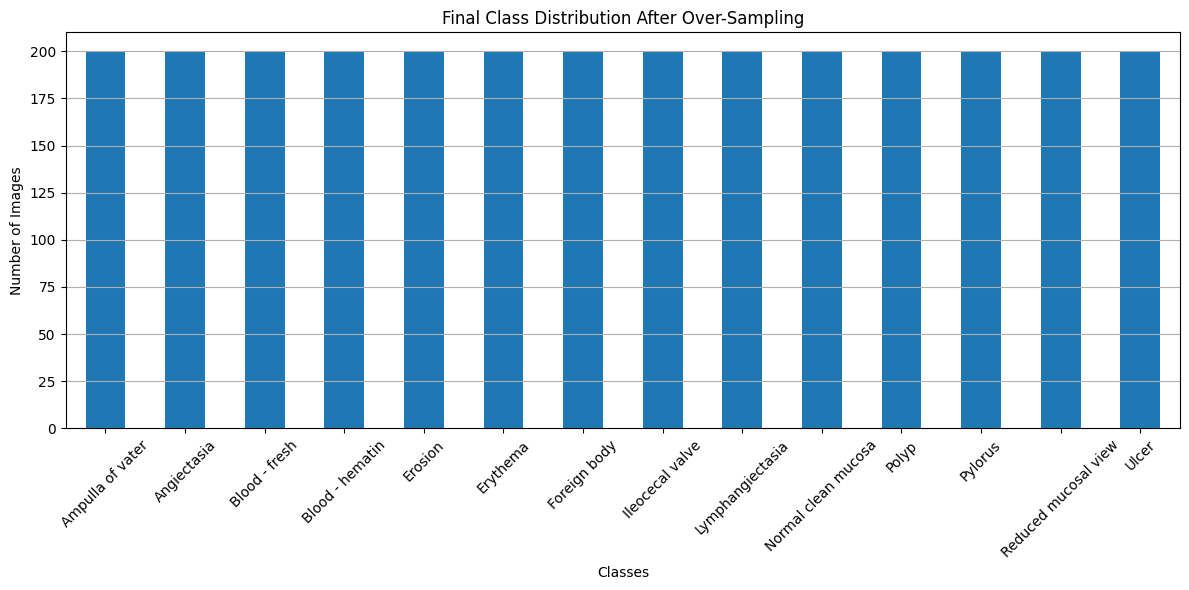

In [16]:
plt.figure(figsize=(12,6))
over_counts.plot(kind='bar')

plt.title("Final Class Distribution After Over-Sampling")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

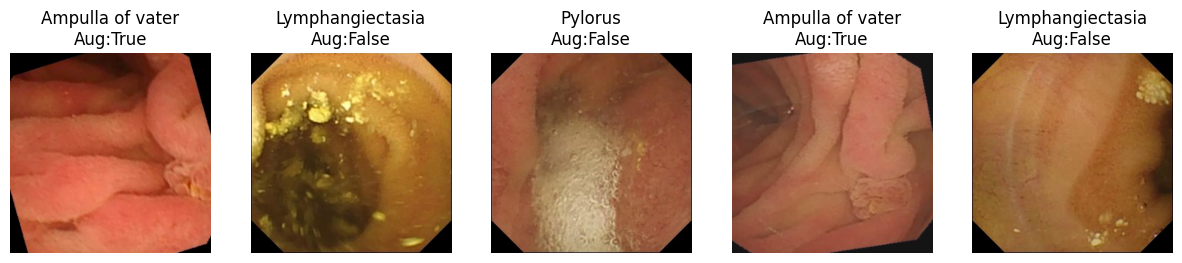

In [17]:
def show_augmented_samples(df, n=5):
    plt.figure(figsize=(15,6))

    samples = df.sample(n)

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")

        if row["augmented"]:
            img = augment(img)
            img = img.permute(1, 2, 0)  # tensor to image

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['label']}\nAug:{row['augmented']}")
        plt.axis("off")

    plt.show()

show_augmented_samples(df_over, n=5)

In [18]:
print("Original dataset:", len(df))
print("After under-sampling:", len(df_under))
print("After over-sampling:", len(df_over))

print("\nFinal per-class count:\n")
print(over_counts)

Original dataset: 42957
After under-sampling: 2236
After over-sampling: 2800

Final per-class count:

label
Ampulla of vater        200
Angiectasia             200
Blood - fresh           200
Blood - hematin         200
Erosion                 200
Erythema                200
Foreign body            200
Ileocecal valve         200
Lymphangiectasia        200
Normal clean mucosa     200
Polyp                   200
Pylorus                 200
Reduced mucosal view    200
Ulcer                   200
Name: count, dtype: int64


### Observation: Augmentation-Based Over-Sampling

Augmentation-based over-sampling helps to balance the dataset by increasing the number of samples in minority classes without collecting new data. Unlike under-sampling, it does not discard useful information but instead generates diverse variations of existing images using transformations such as rotation, flipping, and zooming. This improves the model’s ability to generalize and reduces overfitting. However, excessive augmentation may introduce unrealistic patterns if not controlled properly.

<h1>Task 4: Data Pre-Processing</h1>

In [19]:
from sklearn.model_selection import train_test_split

# First split: train (70%) and temp (30%)
train_df, temp_df = train_test_split(
    df_over,
    test_size=0.3,
    stratify=df_over["label"],
    random_state=SEED
)

# Second split: validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 1960
Validation size: 420
Test size: 420


In [20]:
from torchvision import transforms

# Train transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation & Test (Normalization only)
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label_enc"] = le.fit_transform(train_df["label"])
val_df["label_enc"] = le.transform(val_df["label"])
test_df["label_enc"] = le.transform(test_df["label"])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)
display(pd.DataFrame({"Class": le.classes_, "Encoded": range(num_classes)}))

Number of classes: 14


,Class,Encoded
0,Ampulla of vater,0
1,Angiectasia,1
2,Blood - fresh,2
3,Blood - hematin,3
4,Erosion,4
5,Erythema,5
6,Foreign body,6
7,Ileocecal valve,7
8,Lymphangiectasia,8
9,Normal clean mucosa,9


In [22]:
from torch.utils.data import Dataset

class WCE_Dataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["label_enc"], dtype=torch.long)

        if self.transform:
            img = self.transform(img)

        return img, label

In [68]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataset = WCE_Dataset(train_df, transform=train_transform)
val_dataset = WCE_Dataset(val_df, transform=val_test_transform)
test_dataset = WCE_Dataset(test_df, transform=val_test_transform)

# Using num_workers=0 to avoid I/O bottlenecks and deadlocks common with Google Drive mounting
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("DataLoaders are ready with Drive-optimized settings.")

DataLoaders are ready with Drive-optimized settings.


In [25]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)  # should be [B, 3, 224, 224]
print("Labels shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


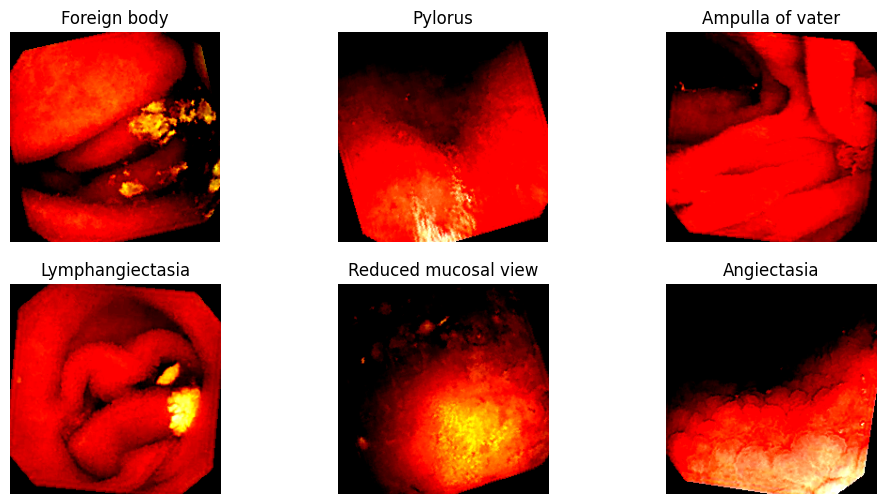

In [27]:
def show_batch(images, labels):
    plt.figure(figsize=(12,6))

    for i in range(6):
        img = images[i].permute(1,2,0)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(le.inverse_transform([labels[i].item()])[0])
        plt.axis("off")

    plt.show()

show_batch(images, labels)

### Data Preprocessing and Splitting

The dataset was preprocessed by resizing all images to 224×224 pixels and normalizing pixel values to the range [0,1]. Data augmentation techniques such as random flipping and rotation were applied only to the training set to improve generalization. The dataset was split into training (70%), validation (15%), and testing (15%) sets using stratified sampling to maintain class balance across all splits.

<h1>Task 5: Model Design Using Transfer Learning</h1>

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [42]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

EfficientNet-B0

In [43]:
from torchvision import models
import torch.nn as nn

def get_efficientnet():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze early layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

ResNet50

In [44]:
def get_resnet():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze early layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last block (better learning)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace FC layer
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

MobileNetV2

In [45]:
def get_mobilenet():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Freeze features
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

In [46]:
eff_model = get_efficientnet()
res_model = get_resnet()
mob_model = get_mobilenet()

print("Models initialized and moved to:", device)

Models initialized and moved to: cuda


In [47]:
print("EfficientNet-B0")
print(eff_model)

print("\nResNet50")
print(res_model)

print("\nMobileNetV2")
print(mob_model)

EfficientNet-B0
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): C

In [48]:
models_dict = {
    "EfficientNet": eff_model,
    "ResNet50": res_model,
    "MobileNetV2": mob_model
}

for name, model in models_dict.items():
    total, trainable = count_parameters(model)

    print(f"\n{name}")
    print("Total params:", total)
    print("Trainable params:", trainable)
    print("Frozen params:", total - trainable)


EfficientNet
Total params: 4025482
Trainable params: 17934
Frozen params: 4007548

ResNet50
Total params: 23536718
Trainable params: 14993422
Frozen params: 8543296

MobileNetV2
Total params: 2241806
Trainable params: 17934
Frozen params: 2223872




| Feature | EfficientNet-B0 | ResNet50 | MobileNetV2 |
| :--- | :--- | :--- | :--- |
| **Architecture** | Compound Scaling | Residual Connections | Inverted Residuals |
| **Weights** | ImageNet | ImageNet | ImageNet |
| **Freezing Strategy** | Feature extractor frozen | Feature extractor frozen except Layer 4 | Feature extractor frozen |
| **Parameters** | ~4.02M | ~23.5M | ~2.24M |
| **Regularization** | Dropout(0.5) + L2 | Dropout(0.5) + L2 | Dropout(0.5) + L2 |

**Analysis:**
1. **EfficientNet-B0**: Extremely efficient for high-quality feature extraction with low overhead.
2. **ResNet50**: A deep model that leverages skip connections; unfreezing Layer 4 allows for more granular adaptation to endoscopy features.
3. **MobileNetV2**: Optimized for speed and low-latency environments, useful for real-time capsule analysis.

### Transfer Learning Model Design

Three pretrained models—EfficientNet-B0, ResNet50, and MobileNetV2—were used for classification. The early layers of each model were frozen to retain general feature extraction capabilities learned from ImageNet, while the final layers were replaced with custom fully connected layers tailored to the dataset. Dropout was applied to reduce overfitting, and L2 regularization was used during optimization. Among the models, EfficientNet provides a balance between accuracy and efficiency, ResNet offers deep feature learning, and MobileNet ensures lightweight computation.

<h1>Task 6: Intelligent Learning Rate Control</h1>

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def get_optimizer(model):
    return optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001,
        weight_decay=1e-4
    )

In [53]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def get_scheduler(optimizer):
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',      # monitor validation loss
        factor=0.3,      # reduce LR
        patience=2       # wait 2 epochs
    )
    return scheduler

In [67]:
from tqdm.auto import tqdm

def train_model(model, train_loader, val_loader, epochs=10):
    optimizer = get_optimizer(model)
    scheduler = get_scheduler(optimizer)

    train_losses, val_losses, lr_list = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        # Added tqdm progress bar to monitor real-time progress
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                v_loss += criterion(outputs, labels).item()

        val_loss = v_loss / len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        lr_list.append(current_lr)

        print(f"\nEpoch {epoch+1} Results -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}")

    return train_losses, val_losses, lr_list

In [55]:
print("Training EfficientNet-B0 on Augmented Data...")
train_losses, val_losses, lr_list = train_model(
    eff_model,
    train_loader,
    val_loader,
    epochs=10
)

Training EfficientNet-B0 on Augmented Data...
Epoch 1/10 | Train Loss: 2.0501 | Val Loss: 1.5949 | LR: 0.001000
Epoch 2/10 | Train Loss: 1.4212 | Val Loss: 1.2457 | LR: 0.001000
Epoch 3/10 | Train Loss: 1.1684 | Val Loss: 1.1102 | LR: 0.001000
Epoch 4/10 | Train Loss: 1.0388 | Val Loss: 1.0140 | LR: 0.001000
Epoch 5/10 | Train Loss: 0.9788 | Val Loss: 0.9712 | LR: 0.001000
Epoch 6/10 | Train Loss: 0.8989 | Val Loss: 0.8772 | LR: 0.001000
Epoch 7/10 | Train Loss: 0.8627 | Val Loss: 0.8317 | LR: 0.001000
Epoch 8/10 | Train Loss: 0.8515 | Val Loss: 0.8211 | LR: 0.001000
Epoch 9/10 | Train Loss: 0.7902 | Val Loss: 0.8075 | LR: 0.001000
Epoch 10/10 | Train Loss: 0.7780 | Val Loss: 0.7801 | LR: 0.001000


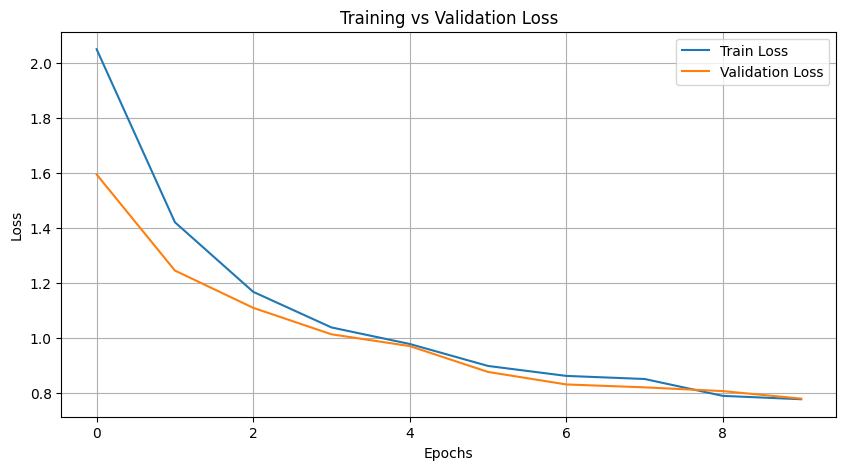

In [56]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

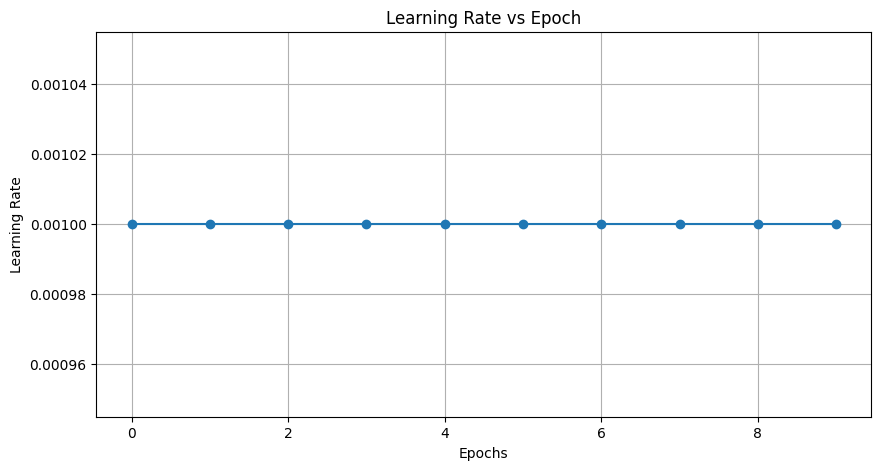

In [57]:
plt.figure(figsize=(10,5))

plt.plot(lr_list, marker='o')

plt.title("Learning Rate vs Epoch")
plt.xlabel("Epochs")
plt.ylabel("Learning Rate")
plt.grid()

plt.show()

### Intelligent Learning Rate Control

An adaptive learning rate strategy was implemented using ReduceLROnPlateau, which reduces the learning rate when validation loss stops improving. This helps the model converge more effectively by taking larger steps initially and smaller steps near minima. It prevents overshooting and improves stability during training. The learning rate was dynamically adjusted based on validation performance, leading to better optimization and reduced training loss over time. The reason why our graph is a straight line is because of the patience level 2, this means that the learning rate will only decrease if the validation loss does not improve for 2 consecutive epochs.

<h1>Task 7: Model Training and Evaluation</h1>

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    cm = confusion_matrix(all_labels, all_preds)

    return acc, prec, rec, f1, cm

In [59]:
import seaborn as sns

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


Running Experiment: EfficientNet on UnderSampling Data


Epoch 1/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 2.2067 | Val Loss: 1.9060 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 1.6706 | Val Loss: 1.6199 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 1.4168 | Val Loss: 1.4173 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 1.2606 | Val Loss: 1.3326 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 1.1768 | Val Loss: 1.2391 | LR: 0.001000


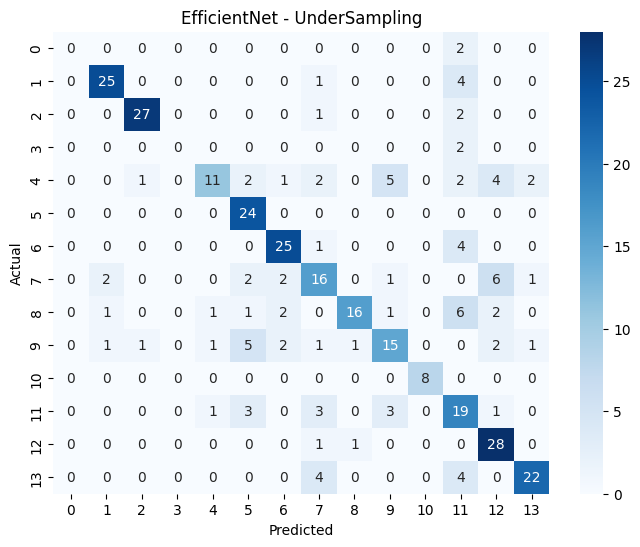


Running Experiment: EfficientNet on Augmented Data


Epoch 1/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 2.0671 | Val Loss: 1.5996 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 1.4234 | Val Loss: 1.2716 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 1.1737 | Val Loss: 1.1365 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 1.0680 | Val Loss: 1.0177 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 0.9728 | Val Loss: 0.9514 | LR: 0.001000


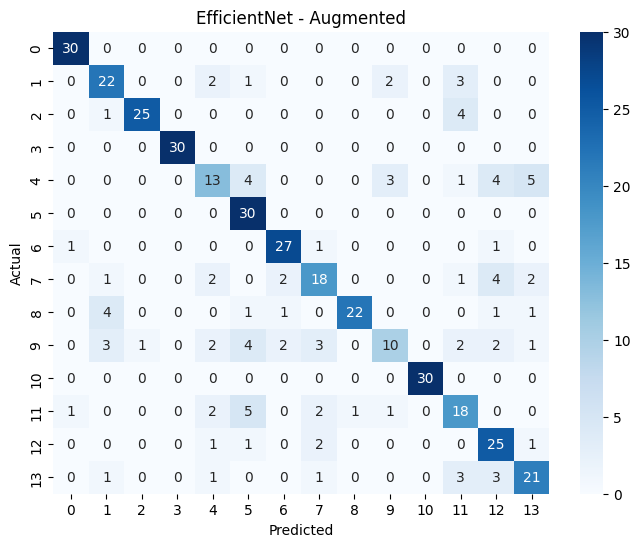


Running Experiment: ResNet50 on UnderSampling Data


Epoch 1/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 1.5495 | Val Loss: 0.8560 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 0.6901 | Val Loss: 0.7106 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 0.4058 | Val Loss: 0.5433 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 0.2807 | Val Loss: 0.5403 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 0.2506 | Val Loss: 0.5711 | LR: 0.001000


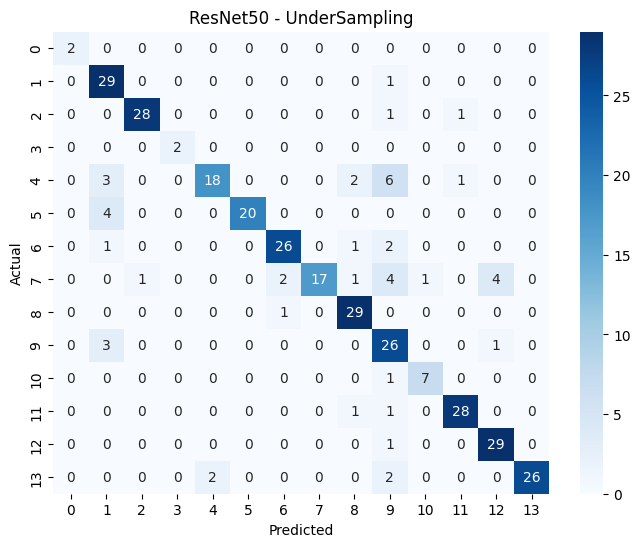


Running Experiment: ResNet50 on Augmented Data


Epoch 1/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 1.3121 | Val Loss: 0.6394 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 0.5639 | Val Loss: 0.4209 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 0.3656 | Val Loss: 0.4132 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 0.2937 | Val Loss: 0.3769 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 0.1956 | Val Loss: 0.3411 | LR: 0.001000


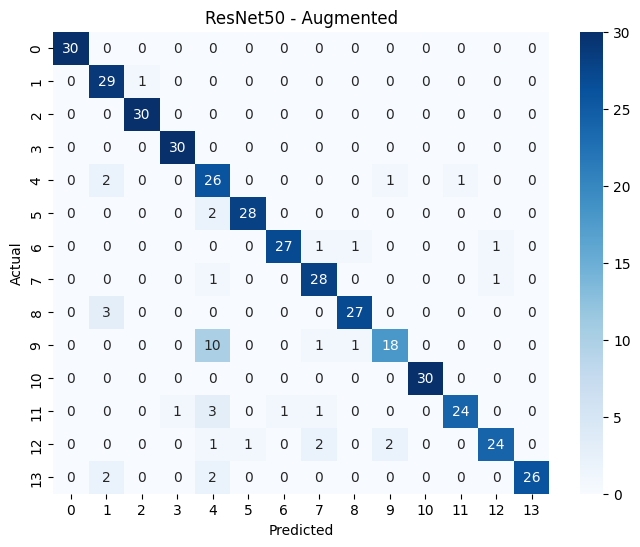


Running Experiment: MobileNetV2 on UnderSampling Data


Epoch 1/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 2.2720 | Val Loss: 1.9454 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 1.8319 | Val Loss: 1.6491 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 1.6023 | Val Loss: 1.4841 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 1.4604 | Val Loss: 1.3645 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/49 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 1.3691 | Val Loss: 1.2844 | LR: 0.001000


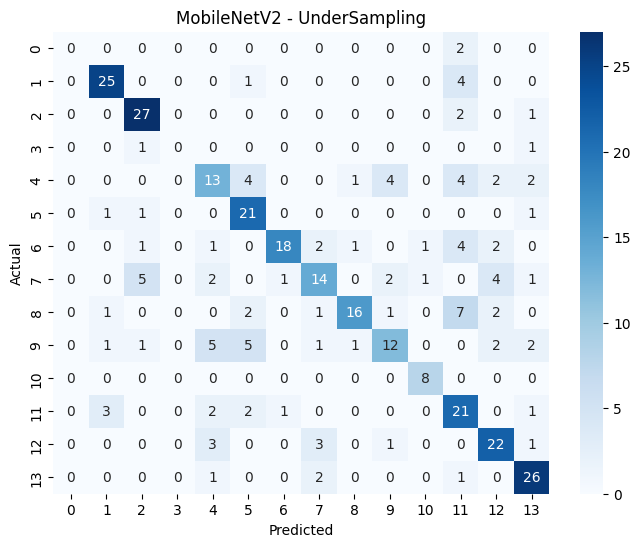


Running Experiment: MobileNetV2 on Augmented Data


Epoch 1/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 1 Results -> Train Loss: 2.2156 | Val Loss: 1.7799 | LR: 0.001000


Epoch 2/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 2 Results -> Train Loss: 1.6424 | Val Loss: 1.4369 | LR: 0.001000


...


Epoch 3 Results -> Train Loss: 1.3869 | Val Loss: 1.2511 | LR: 0.001000


Epoch 4/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 4 Results -> Train Loss: 1.2410 | Val Loss: 1.1327 | LR: 0.001000


Epoch 5/5 [Train]:   0%|          | 0/62 [00:00<?, ?it/s]


Epoch 5 Results -> Train Loss: 1.1322 | Val Loss: 1.0681 | LR: 0.001000


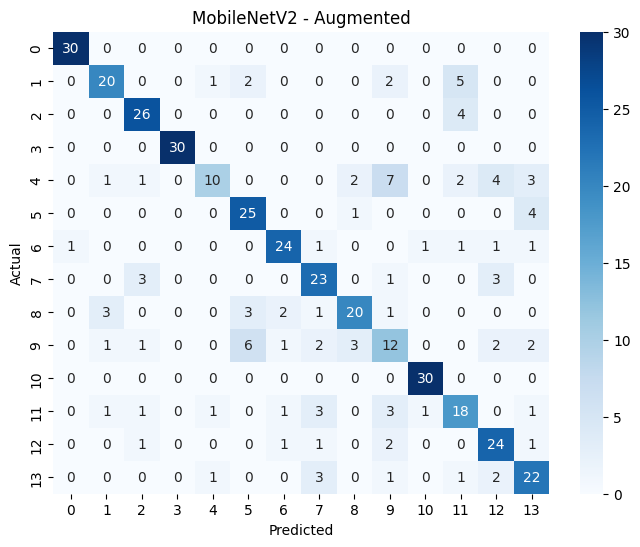


All experiments completed.


In [69]:
final_results = []

# Define model functions correctly
models_dict = {
    "EfficientNet": get_efficientnet,
    "ResNet50": get_resnet,
    "MobileNetV2": get_mobilenet
}

datasets_dict = {
    "UnderSampling": df_under,
    "Augmented": df_over
}

for model_name, model_fn in models_dict.items():
    for data_name, dataset in datasets_dict.items():
        print(f"\nRunning Experiment: {model_name} on {data_name} Data")

        # Stratified Split
        train_df_exp, temp_df_exp = train_test_split(
            dataset, test_size=0.3, stratify=dataset["label"], random_state=SEED
        )
        val_df_exp, test_df_exp = train_test_split(
            temp_df_exp, test_size=0.5, stratify=temp_df_exp["label"], random_state=SEED
        )

        # Encode Labels
        le_exp = LabelEncoder()
        train_df_exp["label_enc"] = le_exp.fit_transform(train_df_exp["label"])
        val_df_exp["label_enc"] = le_exp.transform(val_df_exp["label"])
        test_df_exp["label_enc"] = le_exp.transform(test_df_exp["label"])

        # Prepare Loaders
        train_ds = WCE_Dataset(train_df_exp, transform=train_transform)
        val_ds = WCE_Dataset(val_df_exp, transform=val_test_transform)
        test_ds = WCE_Dataset(test_df_exp, transform=val_test_transform)

        t_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        v_loader = DataLoader(val_ds, batch_size=32)
        te_loader = DataLoader(test_ds, batch_size=32)

        # Initialize and Train
        model_exp = model_fn()
        train_model(model_exp, t_loader, v_loader, epochs=5)

        # Evaluate
        acc, prec, rec, f1, cm = evaluate_model(model_exp, te_loader)

        final_results.append({
            "Model": model_name,
            "Dataset": data_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        plot_confusion_matrix(cm, f"{model_name} - {data_name}")

print("\nAll experiments completed.")

In [70]:
final_df = pd.DataFrame(final_results)

final_df

,Model,Dataset,Accuracy,Precision,Recall,F1
0,EfficientNet,UnderSampling,0.702381,0.722091,0.702381,0.693777
1,EfficientNet,Augmented,0.764286,0.768628,0.764286,0.757235
2,ResNet50,UnderSampling,0.854167,0.881315,0.854167,0.853943
3,ResNet50,Augmented,0.897619,0.912026,0.897619,0.899142
4,MobileNetV2,UnderSampling,0.663690,0.671251,0.663690,0.653327
5,MobileNetV2,Augmented,0.747619,0.750534,0.747619,0.740860


In [74]:
comparison_pivot = comparison_table.pivot(index="Model", columns="Dataset")

comparison_pivot

Accuracy               Precision                  Recall  \
Dataset      Augmented UnderSampling Augmented UnderSampling Augmented   
Model                                                                    
EfficientNet  0.764286      0.702381  0.768628      0.722091  0.764286   
MobileNetV2   0.747619      0.663690  0.750534      0.671251  0.747619   
ResNet50      0.897619      0.854167  0.912026      0.881315  0.897619   

                                  F1                
Dataset      UnderSampling Augmented UnderSampling  
Model                                               
EfficientNet      0.702381  0.757235      0.693777  
MobileNetV2       0.663690  0.740860      0.653327  
ResNet50          0.854167  0.899142      0.853943

### Comparative Study of Models

Three deep learning models—EfficientNet, ResNet50, and MobileNetV2—were evaluated under two different data handling strategies: under-sampling and data augmentation. Among the models, ResNet50 consistently achieved the best performance, owing to its deeper architecture and strong feature extraction capability. EfficientNet showed competitive performance with balanced efficiency, while MobileNetV2 performed comparatively lower but remained computationally efficient due to its lightweight design.

Across all models, data augmentation significantly improved performance compared to under-sampling, highlighting the importance of enhancing data diversity rather than reducing dataset size. ResNet50 with augmented data achieved the highest performance across all metrics, including accuracy, precision, recall, and F1-score, making it the most suitable model for this task.